<a href="https://colab.research.google.com/github/leonardolamvuong/ArmsTransfer_LeonardoVuong/blob/main/Arms_transfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

!pip install scikit-learn
from sklearn import datasets, model_selection
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_regression

from scipy.stats import ttest_rel
from scipy.stats import ttest_ind


!git clone https://github.com/leonardolamvuong/ArmsTransfer_LeonardoVuong.git
#afghanistan array ['Mujahedin (Afghanistan)', 'Afghanistan', 'Iran', 'Iraq', 'Syria', 'Syria rebels', "Yemen", 'Saudi Arabia', "Bahrain", "Israel", "Lebanon", "Kuwait", " Yemen", "North Yemen", "Qatar", "Jordan", "United Arab Emirates"]

Cloning into 'ArmsTransfer_LeonardoVuong'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 6 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), done.


In [13]:
df_arms = pd.read_csv('https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/Arms%20Transfers/arms_transfers_clean.csv')
df_arms = df_arms.dropna(axis = 0, how='any', subset = ['Deliveries in the Year Range', "Year(s) of delivery", 'Number ordered'])  #null values remove too much data from drones, so i'm not removing for the time being.
df_arms.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9296 entries, 0 to 9755
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Recipient                       9296 non-null   object 
 1   Supplier                        9296 non-null   object 
 2   Year of order                   9296 non-null   int64  
 3   Number ordered                  9296 non-null   float64
 4   Weapon designation              9296 non-null   object 
 5   Weapon description              9296 non-null   object 
 6   Deliveries in the Year Range    9296 non-null   float64
 7   Year(s) of delivery             9296 non-null   object 
 8   status                          9296 non-null   object 
 9   SIPRI TIV per unit              9296 non-null   float64
 10  SIPRI TIV for total order       9296 non-null   float64
 11  SIPRI TIV of delivered weapons  9296 non-null   float64
dtypes: float64(5), int64(1), object(6)
memo

In [14]:
df_arms['Year(s) of delivery'] = df_arms['Year(s) of delivery'].astype(str).str.split(';')
df_arms['Year(s) of delivery'] = df_arms['Year(s) of delivery'].apply(lambda lst: [int(x) for x in lst])
df_arms['Delivery Time'] = df_arms['Year(s) of delivery'].apply(lambda x:max(x) - min(x) if len(x) != 1 else 1)
df_arms['Delivery Time']

,Delivery Time
0,1
1,1
2,3
3,1
4,1
...,...
9751,1
9752,1
9753,1
9754,1


Text(0.5, 1.0, 'Number of Weapons supplied to middle east per year')

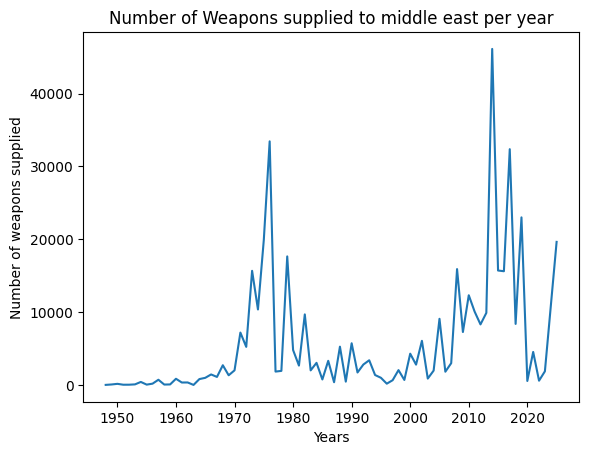

In [4]:
array = ['Mujahedin (Afghanistan)', 'Afghanistan', 'Iran', 'Iraq', 'Syria', 'Syria rebels', "Yemen", 'Saudi Arabia', "Bahrain", "Israel", "Lebanon", "Kuwait", " Yemen", "North Yemen", "Qatar", "Jordan", "United Arab Emirates"]
mE = df_arms[df_arms['Recipient'].isin(array)]
filter = mE.groupby('Year of order')['Number ordered'].sum()
plt.plot(filter.index, filter.values)
plt.xlabel('Years')
plt.ylabel('Number of weapons supplied')
plt.title('Number of Weapons supplied to middle east per year')

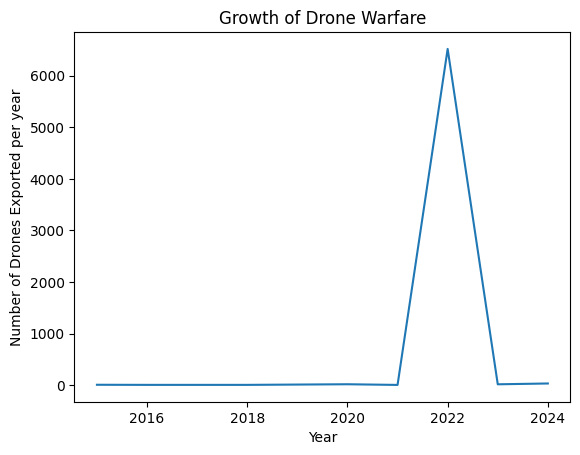

In [ ]:
df_arms['drone'] = df_arms['Weapon description'].replace({'armed drone': 'drone', "one-way attack drone": 'drone'})
drone = df_arms[df_arms['drone'] == 'drone'].groupby('Year of order')['Number ordered'].sum()
drone = drone[drone.index > 2012]
plt.xlabel('Year')
plt.ylabel('Number of Drones Exported per year')
plt.title('Growth of Drone Warfare')
plt.plot(drone.index, drone.values)



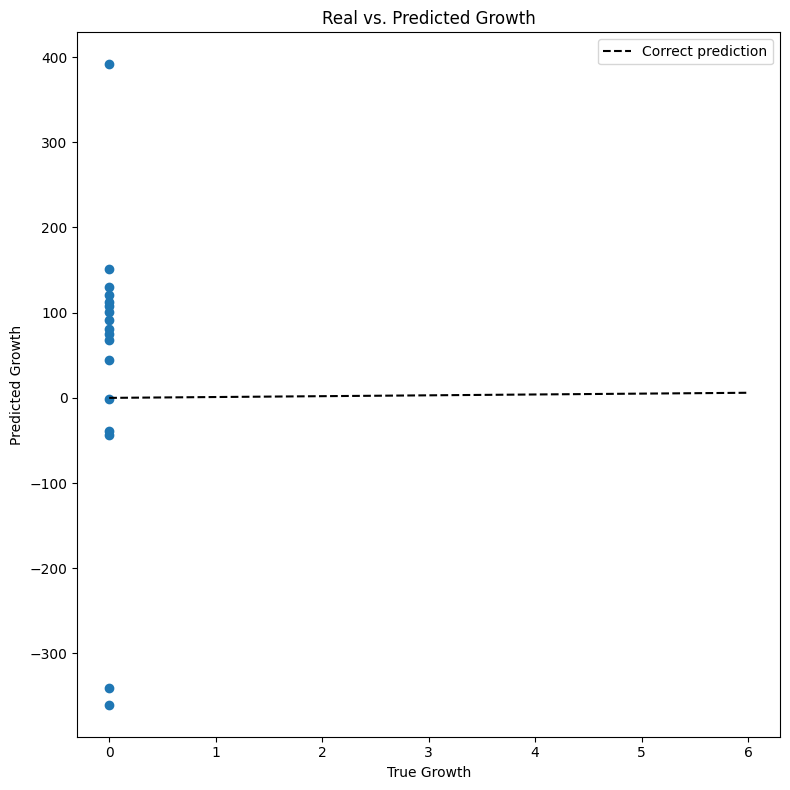

In [ ]:
drone_reg = df_arms[(df_arms['Weapon description'] == 'one-way attack drone') | (df_arms['Weapon description'] == 'armed drone')]
label = drone_reg.groupby('Year of order')['Number ordered'].sum()
features = df_arms.groupby('Year of order')[['Year of order','SIPRI TIV for total order', 'SIPRI TIV of delivered weapons']].sum()
data = features.join(label.rename('drone ordered'), how= 'left').fillna({'drone ordered': 0})
new_features = data[['Year of order', 'SIPRI TIV for total order', 'SIPRI TIV of delivered weapons']]
new_label = data['drone ordered']
X_train, X_test, y_train, y_test = model_selection.train_test_split(new_features, new_label, test_size = 0.2, random_state = 42)
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X_train, y_train)
pred = reg.predict(X_test)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, pred)
plt.plot([0, 6], [0, 6], '--k', label="Correct prediction")
plt.xlabel('True Growth')
plt.ylabel('Predicted Growth')
plt.title("Real vs. Predicted Growth")
plt.axis('tight')
plt.legend()
plt.tight_layout()


In [ ]:
from sklearn.metrics import* #imports all metric functions
print('mean squared: ', mean_squared_error(y_test, pred))

print('r squared: ', r2_score(y_test, pred))
print("MSE", mean_absolute_error(y_test, pred)) #I think i was a  bit too hasty with tyring to regress after realizing KNN wouldnt work for the application i was going for
# It makes a lot of sense why this wouldnt work.

mean squared:  30480.171093049452
r squared:  0.0
MSE 132.86459923923564


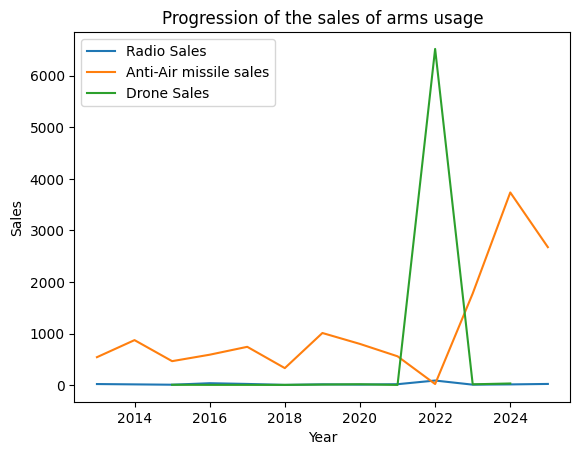

In [ ]:

df_arms['detection'] = df_arms['Weapon description'].replace({'ground surveillance radar': 'radar','sea-search radar': 'radar','airborne early-warning radar': 'radar','air-search/fire-control radar': 'radar','air/sea-search radar': 'radar','multi-role radar': 'radar','air-search radar': 'radar'})
rad = df_arms[df_arms['detection'] == 'radar'].groupby('Year of order')['Number ordered'].sum()
rad = rad[rad.index > 2012]
plt.plot(rad.index, rad.values, label = "Radio Sales")
df_arms['anti'] = df_arms['Weapon description'].replace({'surface-to-air missile': 'missile', 'surface-to-air missile system': 'missile', 'mobile surface-to-air missile system':'missile', 'portable surface-to-air missile': 'missile', 'naval surface-to-air missile system': 'missile', 'anti-aircraft gun':'missile', 'self-propelled anti-aircraft gun':'missile'})
mis = df_arms[df_arms['anti'] == 'missile'].groupby('Year of order')['Number ordered'].sum()
mis = mis[mis.index > 2012]
plt.plot(mis.index, mis.values, label='Anti-Air missile sales')
plt.plot(drone.index, drone.values, label='Drone Sales')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.title('Progression of the sales of arms usage')
plt.legend()

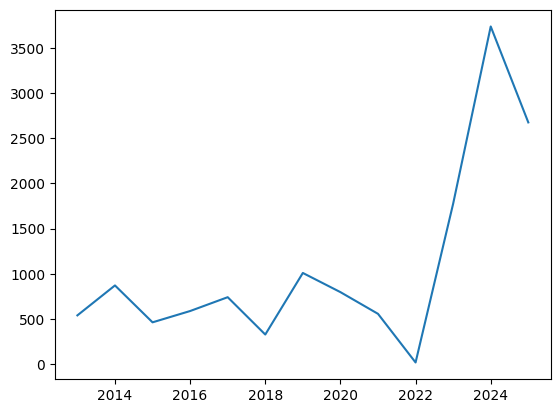

In [ ]:

df_arms['anti'] = df_arms['Weapon description'].replace({'surface-to-air missile': 'missile', 'surface-to-air missile system': 'missile', 'mobile surface-to-air missile system':'missile', 'portable surface-to-air missile': 'missile', 'naval surface-to-air missile system': 'missile', 'anti-aircraft gun':'missile', 'self-propelled anti-aircraft gun':'missile'})
mis = df_arms[df_arms['anti'] == 'missile'].groupby('Year of order')['Number ordered'].sum()
mis = mis[mis.index > 2012]
plt.plot(mis.index, mis.values)

In [ ]:
df_arms.loc[df_arms.isnull().any(axis=1)]
df_arms = df_arms.dropna(axis = 0, how='any', subset = ['Deliveries in the Year Range', "Year(s) of delivery", 'Number ordered'])  #null values remove too much data from drones, specifically
#df_arms = df_arms.fillna("null")
df_arms.info()


<class 'pandas.core.frame.DataFrame'>
Index: 9296 entries, 0 to 9755
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Recipient                       9296 non-null   object 
 1   Supplier                        9296 non-null   object 
 2   Year of order                   9296 non-null   int64  
 3   Number ordered                  9296 non-null   float64
 4   Weapon designation              9296 non-null   object 
 5   Weapon description              9296 non-null   object 
 6   Deliveries in the Year Range    9296 non-null   float64
 7   Year(s) of delivery             9296 non-null   object 
 8   status                          9296 non-null   object 
 9   SIPRI TIV per unit              9296 non-null   float64
 10  SIPRI TIV for total order       9296 non-null   float64
 11  SIPRI TIV of delivered weapons  9296 non-null   float64
 12  drone                           9296 no

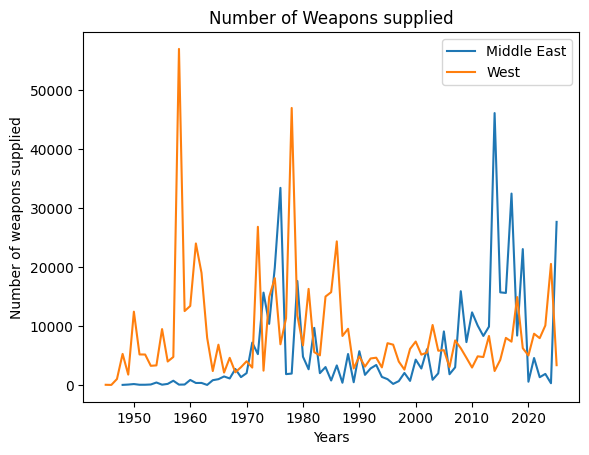

In [ ]:
#How do arms transfer relationships (volume,  quality, TIV) from the West differ from the Middle East?
arraymiddle = ['Mujahedin (Afghanistan)', 'Afghanistan', 'Iran', 'Iraq', 'Syria', 'Syria rebels', "Yemen", 'Saudi Arabia', "Bahrain", "Israel", "Lebanon", "Kuwait", " Yemen", "North Yemen", "Qatar", "Jordan", "United Arab Emirates"]
mE = df_arms[df_arms['Recipient'].isin(arraymiddle)]
filter = mE.groupby('Year of order')['Number ordered'].sum()
plt.plot(filter.index, filter.values, label='Middle East')
plt.xlabel('Years')
plt.ylabel('Number of weapons supplied')
plt.title('Number of Weapons supplied')
arrayWest = ['Poland,', 'Hungary', 'Australia','Austria','Belgium','Canada','Croatia','Czechia','Denmark','Estonia','Finland','France','Germany','Greece','Ireland','Italy','Japan','Latvia','Lithuania','Luxembourg','Netherlands','New Zealand','North Macedonia','Norway','Portugal','Romania','Slovakia','Slovenia','South Korea','Spain','Sweden','Switzerland',  'United Kingdom','United States']
west = df_arms[df_arms['Recipient'].isin(arrayWest)]
filter2 = west.groupby('Year of order')['Number ordered'].sum()
plt.plot(filter2.index, filter2.values, label='West')
plt.legend()


In [ ]:
mE[(mE['Recipient'] == 'Israel') & (mE['Year of order'] > 2002)]

,Recipient,Supplier,Year of order,Number ordered,Weapon designation,Weapon description,Deliveries in the Year Range,Year(s) of delivery,status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons,drone
3467,Israel,United States,2025,2166.0,GBU-39 SDB,guided glide bomb,100.0,2025,New,0.02,43.32,2.00,guided glide bomb
3469,Israel,United States,2006,50.0,M-106A3,self-propelled mortar,50.0,2007; 2008; 2009,Second hand,0.22,11.00,11.00,self-propelled mortar
3471,Israel,United States,2025,17479.0,JDAM,guided bomb,1000.0,2025,New,0.02,349.58,20.00,guided bomb
3475,Israel,United States,2004,500.0,Paveway,guided bomb,500.0,2005; 2006,New,0.02,10.00,10.00,guided bomb
3479,Israel,United States,2004,840.0,JDAM,guided bomb,840.0,2005,New,0.02,16.80,16.80,guided bomb
3480,Israel,United States,2011,531.0,Namer,armoured personnel carrier,477.0,2014; 2015; 2016; 2017; 2018; 2019; 2020; 2021...,New,1.50,796.50,715.50,armoured personnel carrier
3482,Israel,United States,2011,160.0,M-106A3,self-propelled mortar,160.0,2012,Second hand,0.22,35.20,35.20,self-propelled mortar
3490,Israel,United States,2007,50.0,GBU-28,guided bomb,50.0,2009,New,0.10,5.00,5.00,guided bomb
3491,Israel,United States,2019,2.0,Kuroda,landing ship,2.0,2023; 2024,New,40.00,80.00,80.00,landing ship
3492,Israel,United States,2017,4100.0,GBU-39 SDB,guided glide bomb,4100.0,2018; 2019; 2020; 2021; 2022,New,0.02,82.00,82.00,guided glide bomb


In [ ]:

mE[(mE['Recipient'] != 'Israel') & (mE['Year of order'] > 2002)]

,Recipient,Supplier,Year of order,Number ordered,Weapon designation,Weapon description,Deliveries in the Year Range,Year(s) of delivery,status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons,drone
0,Afghanistan,United States,2015,55.0,M-1117 Guardian,armoured personnel carrier,55.0,2015,New,0.40,22.0,22.0,armoured personnel carrier
1,Afghanistan,United States,2004,188.0,M-113,armoured personnel carrier,188.0,2005,Second hand,0.10,18.8,18.8,armoured personnel carrier
2,Afghanistan,United States,2017,1673.0,HMMWV-UA,armoured personnel carrier,1673.0,2018; 2019; 2020; 2021,Second hand,0.05,87.0,87.0,armoured personnel carrier
3,Afghanistan,United States,2006,800.0,HMMWV-UA,armoured personnel carrier,800.0,2007; 2008,Second hand,0.05,41.6,41.6,armoured personnel carrier
4,Afghanistan,United States,2011,41.0,M-1117 Guardian,armoured personnel carrier,41.0,2011; 2012,New,0.40,16.4,16.4,armoured personnel carrier
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9714,Yemen,United States,2010,4.0,UH-1H Huey-2,helicopter,4.0,2011,New,3.10,12.4,12.4,helicopter
9715,Yemen,United States,2011,2.0,aircraft engine,aircraft engine,2.0,2013,New,0.50,1.0,1.0,aircraft engine
9716,Yemen,United States,2014,1.0,King Air-350 ISR,ground surveillance aircraft,1.0,2015,New,11.00,11.0,11.0,ground surveillance aircraft
9717,Yemen,United States,2005,32.0,M-113,armoured personnel carrier,32.0,2006,Second hand,0.10,3.2,3.2,armoured personnel carrier


In [ ]:
tstat, pval = stats.ttest_ind(filter, filter2)
print(pval)

0.08577936232325015


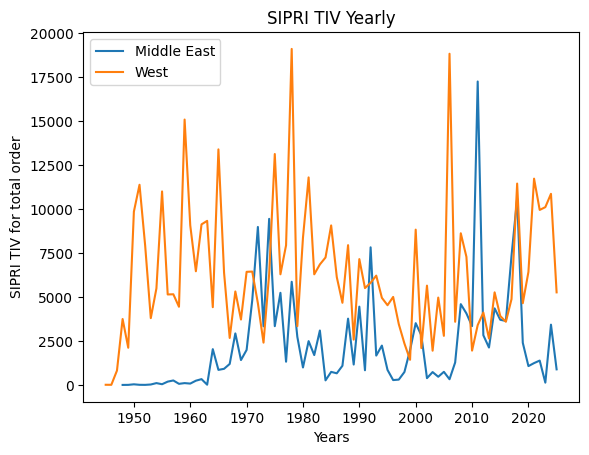

In [ ]:
filter3 = mE.groupby('Year of order')['SIPRI TIV for total order'].sum()
plt.plot(filter3.index, filter3.values, label='Middle East')
plt.xlabel('Years')
plt.ylabel('SIPRI TIV for total order')
plt.title('SIPRI TIV Yearly')
filter4 = west.groupby('Year of order')['SIPRI TIV for total order'].sum()
plt.plot(filter4.index, filter4.values, label='West')
plt.legend()


In [ ]:
tstat2, pval2 = stats.ttest_ind(filter3, filter4)
print(pval2)

3.5819827983469556e-10


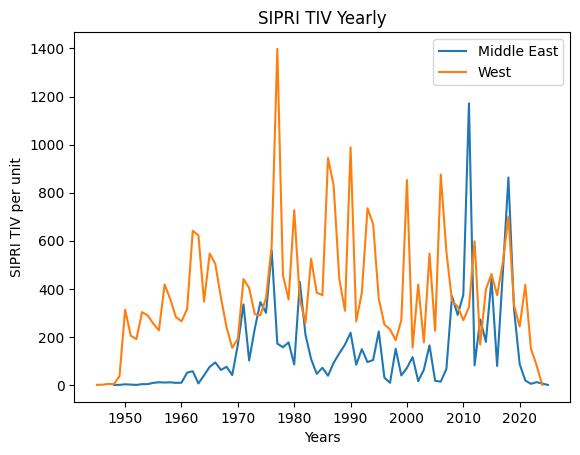

In [ ]:
filter5 = mE.groupby('Year of order')['SIPRI TIV per unit'].sum()
plt.plot(filter5.index, filter5.values, label='Middle East')
plt.xlabel('Years')
plt.ylabel('SIPRI TIV per unit')
plt.title('SIPRI TIV Yearly')
filter6 = west.groupby('Year of order')['SIPRI TIV per unit'].sum()
plt.plot(filter6.index, filter6.values, label='West')
plt.legend()

In [ ]:
tstat3, pval3 = stats.ttest_ind(filter5, filter6)
print(pval3)

3.402374698558509e-10


In [ ]:
test = df_arms['Number ordered'].var()
print(test)
test2= df_arms['Deliveries in the Year Range']
print(test2)

989950.853542184
0         55.0
1        188.0
2       1673.0
3        800.0
4         41.0
         ...  
9751       1.0
9752       1.0
9753       4.0
9754       2.0
9755       1.0
Name: Deliveries in the Year Range, Length: 9296, dtype: float64


In [ ]:
df_arms = df_arms.dropna(axis = 0, how='any', subset = ['Deliveries in the Year Range', "Year(s) of delivery", 'Number ordered'])

# Afghan


In [ ]:
Afghan = df_arms[df_arms['Recipient'] == 'Afghanistan']
Afghan_filtered = Afghan.groupby('Year of order')['Number ordered'].sum()
final_afghan = Afghan_filtered[(Afghan_filtered.index > 2001) & (Afghan_filtered.index < 2008)]
#plt.plot(final_afghan.index, final_afghan.values)
afghan_war = Afghan_filtered[(Afghan_filtered.index >= 2006)]
#plt.plot(afghan_war.index, afghan_war.values)
t_stat, p_value = ttest_ind(final_afghan, afghan_war)
print(p_value) # for number ordered
x = final_afghan.mean()
y= afghan_war.mean()

print((y - x)/x * 100)


0.4743131687642178
281.140350877193


In [ ]:
Afghan = df_arms[df_arms['Recipient'] == 'Afghanistan']
Afghan_filtered2 = Afghan.groupby('Year of order')['Delivery Time'].sum()
final_afghan = Afghan_filtered2[(Afghan_filtered2.index > 2001) & (Afghan_filtered2.index <= 2008)]
#plt.plot(final_afghan.index, final_afghan.values)
afghan_war = Afghan_filtered2[(Afghan_filtered2.index > 2009)]
#plt.plot(afghan_war.index, afghan_war.values)
t_stat, p_value = ttest_ind(final_afghan, afghan_war)
print(p_value)
x = final_afghan.mean()
y= afghan_war.mean()

print((y - x)/x * 100)

0.21988784312755905
127.99999999999996


In [25]:
Afghan = df_arms[df_arms['Recipient'] == 'Afghanistan']
Afghan_filtered3 = Afghan.groupby('Year of order')['SIPRI TIV for total order'].sum()
final_afghan = Afghan_filtered3[(Afghan_filtered3.index > 2001) & (Afghan_filtered3.index <= 2008)]
#plt.plot(final_afghan.index, final_afghan.values)
afghan_war = Afghan_filtered3[(Afghan_filtered3.index > 2009) | (Afghan_filtered3.index <=2001)]
#plt.plot(afghan_war.index, afghan_war.values)
t_stat, p_value = ttest_ind(final_afghan, afghan_war)
print(p_value)
x = final_afghan.mean()
y= afghan_war.mean()

print((y - x)/x * 100)

0.9364595732782524
6.9281751608846935


#Bahrain


In [ ]:
Bah = df_arms[df_arms['Recipient'] == 'Bahrain']
bahfilt1 = Bah.groupby('Year of order')['Number ordered'].sum()
bahwarfinal = bahfilt1[(bahfilt1.index == 2011) | (bahfilt1.index == 2012)]
bahpeacefinal = bahfilt1[(bahfilt1.index != 2011) & (bahfilt1.index != 2012)]
t_stat, p_value = ttest_ind(bahpeacefinal, bahwarfinal)
print(p_value)
x = bahwarfinal.mean()
y = bahpeacefinal.mean()
print((y - x)/x * 100)

0.7147935511571283
118.29268292682926


In [ ]:
Bah = df_arms[df_arms['Recipient'] == 'Bahrain']
bahfilt2 = Bah.groupby('Year of order')['Delivery Time'].sum()
bahwarfinal = bahfilt2[(bahfilt2.index == 2011) | (bahfilt2.index == 2012)]
bahpeacefinal = bahfilt2[(bahfilt2.index != 2011) & (bahfilt2.index != 2012)]
t_stat, p_value = ttest_ind(bahpeacefinal, bahwarfinal)
print(p_value)
x = bahwarfinal.mean()
y = bahpeacefinal.mean()
x = bahwarfinal.mean()
y = bahpeacefinal.mean()
print((y - x)/x * 100)


0.7769849959335656
23.529411764705888


In [ ]:
Bah = df_arms[df_arms['Recipient'] == 'Bahrain']
bahfilt3 = Bah.groupby('Year of order')['SIPRI TIV for total order'].sum()
bahwarfinal = bahfilt3[(bahfilt3.index == 2011) | (bahfilt3.index == 2012)]
bahpeacefinal = bahfilt3[(bahfilt3.index != 2011) & (bahfilt3.index != 2012)]
t_stat, p_value = ttest_ind(bahpeacefinal, bahwarfinal)
print(p_value)
x = bahwarfinal.mean()
y = bahpeacefinal.mean()
print((y - x)/x * 100)

0.6379334697576906
151.50871031837713


#Arab Spring

In [10]:
spring = ['Bahrain','Tunisia','Egypt', 'Libya', 'Yemen', 'Syria', 'Morocco', 'Algeria', 'Jordan', 'Iraq', 'Lebanon', 'Kuwait', 'Oman', 'Sudan']
springArab = df_arms[df_arms['Recipient'].isin(spring)]
filtered_spring = springArab.groupby('Year of order')['Number ordered'].sum()
protest_time = filtered_spring[(filtered_spring >= 2009) | (filtered_spring <= 2012)]
no_protest = filtered_spring[(filtered_spring >2012) | (filtered_spring < 2009) & (filtered_spring > 2000)]
t_stat, p_value = ttest_ind(protest_time, no_protest)
print(p_value)
x = protest_time.mean()
y = no_protest.mean()
print((y - x)/x * 100)

4.386116410342186e-07
185.56284994583586


In [61]:
spring = ['Bahrain','Tunisia','Egypt', 'Libya', 'Yemen', 'Syria', 'Morocco', 'Algeria', 'Jordan', 'Iraq', 'Lebanon', 'Kuwait', 'Oman', 'Sudan']
springArab = df_arms[df_arms['Recipient'].isin(spring)]
filtered_spring = springArab.groupby('Year of order')['Delivery Time'].sum()
protest_time = filtered_spring[(filtered_spring >= 2009) | (filtered_spring <= 2012)]
no_protest = filtered_spring[(filtered_spring >2012) | (filtered_spring < 2009) & (filtered_spring > 2000)]
t_stat, p_value = ttest_ind(protest_time, no_protest)
print(p_value)
x = protest_time.mean()
y = no_protest.mean()
print((y - x)/x * 100)

nan
nan


In [24]:
filtered_spring = springArab.groupby('Year of order')['SIPRI TIV for total order'].sum()
protest_time = filtered_spring[(filtered_spring >= 2009) | (filtered_spring <= 2012)]
no_protest = filtered_spring[(filtered_spring >2012) | (filtered_spring < 2009) & (filtered_spring > 2000)]
t_stat, p_value = ttest_ind(protest_time, no_protest)
print(p_value)
x = protest_time.mean()
y = no_protest.mean()
print((y - x)/x * 100)

1.1591586698103527e-07
237.26235080598718


#Anti Austerity

In [55]:
protest_nations = ['Italy', 'Greece', 'Ireland', 'Portugal', 'Spain', 'Cyprus', 'Belgium', 'Poland']
austerity = df_arms[df_arms['Recipient'].isin(protest_nations)]
filter = austerity.groupby('Year of order')['Number ordered'].sum()
protest_time = filter[(filter.index >=2010) & (filter.index <= 2014)]
no_protest = filter[(filter.index >2014) | (filter.index < 2010) & (filter.index > 2000)]
t_stat, p_value = ttest_ind(protest_time, no_protest)
print(p_value)
x = protest_time.mean()
y = no_protest.mean()
print((y - x)/x * 100)



0.193434310257867
70.28657326215573


In [56]:
filter = austerity.groupby('Year of order')['SIPRI TIV for total order'].sum()
protest_time = filter[(filter.index >=2010) & (filter.index <= 2014)]
no_protest = filter[(filter.index >2014) | (filter.index < 2010) & (filter.index > 2000)]
t_stat, p_value = ttest_ind(protest_time, no_protest)
print(p_value)
x = protest_time.mean()
y = no_protest.mean()
print((y - x)/x * 100)

0.1830635471326565
1172.227945197289


#France


In [42]:
france = df_arms[df_arms['Recipient'] == "France"]
filter = france.groupby('Year of order')['SIPRI TIV for total order'].sum()
protest_time = filter[(filter.index >=2017) & (filter.index <= 2021)]
no_protest_france = filter[(filter.index >2020) | (filter.index < 2018) & (filter.index > 2000)]
t_stat, p_value = ttest_ind(protest_time, no_protest_france)
print(p_value)
#x = protest_time.mean()
#y = no_protest.mean()
#print((y - x)/x * 100)


0.2884304734161347
